# Pregunta 1

#### 1. Imagen sintetica, regiones y ruido Poisson

La convencion de coordenadas usa `meshgrid(..., indexing='ij')`, por lo que la primera dimension representa filas y la segunda columnas. El cuadrado ocupa 128x128 pixeles y el circulo se define con una desigualdad inclusiva <= para incluir todos sus pixeles

Media y: 0.2421; desviacion estandar y-x: 0.0782
Fondo (0.15)                : pixeles=49152, media y=0.1499, RMSE ruido=0.0614
Cuadrado sin circulo (0.45) : pixeles=13156, media y=0.4498, RMSE ruido=0.1062
Circulo (0.80)              : pixeles= 3228, media y=0.7996, RMSE ruido=0.1436


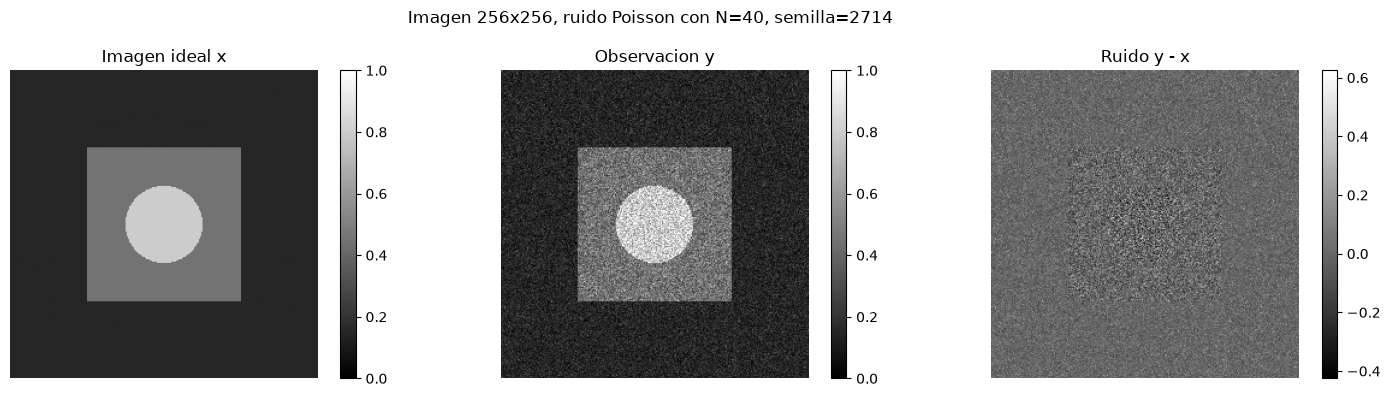

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, gaussian_filter

NPIX = 256
PHOTONS = 40
SEED = 2714
rng = np.random.default_rng(SEED)

yy, xx = np.indices((NPIX, NPIX), dtype=float)
centro = (NPIX - 1) / 2
cuadrado = (xx >= 64) & (xx < 192) & (yy >= 64) & (yy < 192)
circulo = (xx - centro) ** 2 + (yy - centro) ** 2 <= 32 ** 2
circulo &= cuadrado

x = np.full((NPIX, NPIX), 0.15, dtype=np.float64)
x[cuadrado] = 0.45
x[circulo] = 0.80

# Las regiones son exhaustivas y disjuntas, incluso en las fronteras.
mascara_fondo = ~cuadrado
mascara_cuadrado = cuadrado & ~circulo
mascara_circulo = circulo
mascaras = {
    "Fondo (0.15)": mascara_fondo,
    "Cuadrado sin circulo (0.45)": mascara_cuadrado,
    "Circulo (0.80)": mascara_circulo,
}
assert np.all((mascara_fondo.astype(int) + mascara_cuadrado + mascara_circulo) == 1)

# y = Poisson(PHOTONS*x)/PHOTONS: la varianza depende de la intensidad.
y = rng.poisson(PHOTONS * x) / PHOTONS

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, image, title in zip(axes, (x, y, y - x), ("Imagen ideal x", "Observacion y", "Ruido y - x")):
    im = ax.imshow(image, cmap="gray", vmin=0 if title != "Ruido y - x" else None,
                   vmax=1 if title != "Ruido y - x" else None)
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"Imagen 256x256, ruido Poisson con N={PHOTONS}, semilla={SEED}")
plt.tight_layout()

print(f"Media y: {y.mean():.4f}; desviacion estandar y-x: {(y-x).std():.4f}")
for name, mask in mascaras.items():
    print(f"{name:28s}: pixeles={mask.sum():5d}, media y={y[mask].mean():.4f}, RMSE ruido={np.sqrt(np.mean((y[mask]-x[mask])**2)):.4f}")

#### 2. Kernel Gaussiano y filtrado global

Para un sigma dado se usa el soporte `[-ceil(3*sigma), ceil(3*sigma)]` en cada dimension. En ese radio queda aproximadamente el 99% de la masa de una Gaussiana unidimensional, despues se renormaliza para que la suma de coeficientes sea 1. El borde se trata con reflexion para evitar crear un borde artificial de ceros.

sigma=1.7: kernel (13, 13), suma=1.000000000000


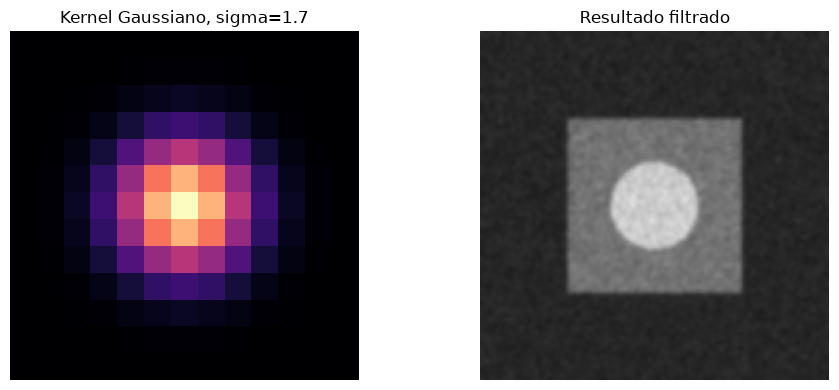

In [2]:
def kernel_gaussiano(sigma):
    """Construye un kernel 2D isotrpico normalizado con soporte 3 sigma."""
    sigma = float(sigma)
    if not np.isfinite(sigma) or sigma <= 0:
        raise ValueError("sigma debe ser un nmero real positivo")
    radio = int(np.ceil(3 * sigma))
    coordenadas = np.arange(-radio, radio + 1, dtype=float)
    X, Y = np.meshgrid(coordenadas, coordenadas, indexing="xy")
    kernel = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    return kernel / kernel.sum()


def filtrar_gaussiano(image, sigma):
    """Filtrado por el kernel construido arriba, sigma puede ser cualquier real > 0."""
    return convolve(image, kernel_gaussiano(sigma), mode="reflect")


def rmse(reference, estimate, mask=None):
    error = reference - estimate
    if mask is not None:
        error = error[mask]
    return float(np.sqrt(np.mean(error**2)))

sigma_demo = 1.7
kernel_demo = kernel_gaussiano(sigma_demo)
print(f"sigma={sigma_demo}: kernel {kernel_demo.shape}, suma={kernel_demo.sum():.12f}")
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(kernel_demo, cmap="magma")
ax[0].set_title(f"Kernel Gaussiano, sigma={sigma_demo}")
ax[1].imshow(filtrar_gaussiano(y, sigma_demo), cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Resultado filtrado")
for a in ax: a.set_axis_off()
plt.tight_layout()


#### 3. Barrido de sigma y RMSE por region

Se incluye `sigma=0` como referencia sin filtrado y se explora un rango de escalas. El mismo barrido se usa para el RMSE global y para cada mascara.

In [3]:
sigmas = np.concatenate(([0.0], np.linspace(0.25, 8.0, 64)))
resultados = {name: [] for name in mascaras}
resultados["Global"] = []
filtradas = {}

for sigma in sigmas:
    estimate = y if sigma == 0 else filtrar_gaussiano(y, sigma)
    filtradas[float(sigma)] = estimate
    resultados["Global"].append(rmse(x, estimate))
    for name, mask in mascaras.items():
        resultados[name].append(rmse(x, estimate, mask))

optimos = {name: int(np.argmin(values)) for name, values in resultados.items()}
for name, index in optimos.items():
    print(f"{name:28s}: sigma optimo={sigmas[index]:.3f}, RMSE={resultados[name][index]:.6f}")


Fondo (0.15)                : sigma optimo=1.849, RMSE=0.016567
Cuadrado sin circulo (0.45) : sigma optimo=1.357, RMSE=0.036869
Circulo (0.80)              : sigma optimo=1.480, RMSE=0.043401
Global                      : sigma optimo=1.480, RMSE=0.024104


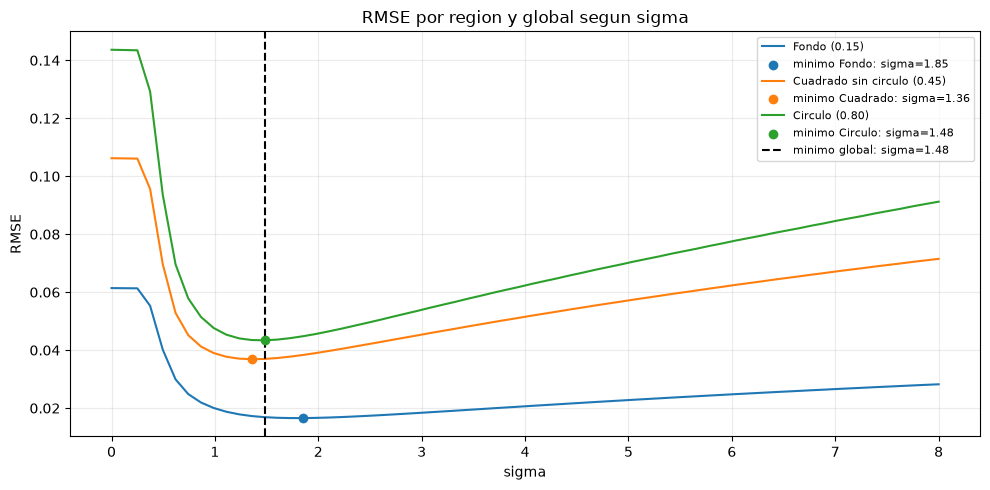

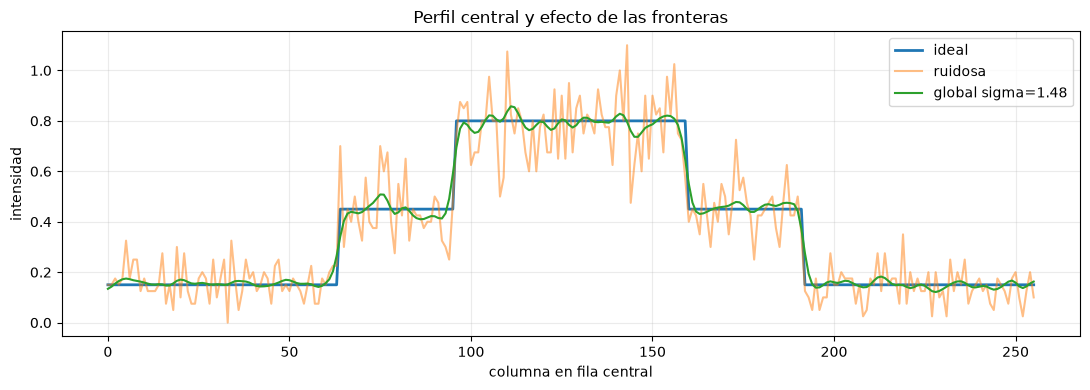

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
colores = {"Fondo (0.15)": "tab:blue", "Cuadrado sin circulo (0.45)": "tab:orange", "Circulo (0.80)": "tab:green"}
for name in mascaras:
    values = np.asarray(resultados[name])
    i = optimos[name]
    ax.plot(sigmas, values, label=name, color=colores[name])
    ax.scatter(sigmas[i], values[i], color=colores[name], zorder=3,
               label=f"minimo {name.split(' ')[0]}: sigma={sigmas[i]:.2f}")
ig = optimos["Global"]
ax.axvline(sigmas[ig], color="black", linestyle="--", label=f"minimo global: sigma={sigmas[ig]:.2f}")
ax.set(xlabel="sigma", ylabel="RMSE", title="RMSE por region y global segun sigma")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()

fila = NPIX // 2
best_global = filtradas[float(sigmas[ig])]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(x[fila], label="ideal", linewidth=2)
ax.plot(y[fila], label="ruidosa", alpha=0.5)
ax.plot(best_global[fila], label=f"global sigma={sigmas[ig]:.2f}")
ax.set(xlabel="columna en fila central", ylabel="intensidad", title="Perfil central y efecto de las fronteras")
ax.legend(); ax.grid(alpha=0.25); plt.tight_layout()


#### 4. Diseno de la regla sigma = F(mu_hat)

Se estima `mu_hat` con un suavizado auxiliar fijo (`sigma_aux=2`). Para evitar que ese estimador transmita demasiado ruido, se interpola linealmente entre los optimos medidos en las intensidades 0.15, 0.45 y 0.80. La interpolacion se limita a `[sigma_min, sigma_max]` y los valores se derivan de la parte anterior.

Nodos de F(mu_hat):
  mu=0.15 -> sigma=1.849
  mu=0.45 -> sigma=1.357
  mu=0.80 -> sigma=1.480
Suavizado auxiliar: sigma_aux=2.0; mapa sigma en [1.357, 1.849]


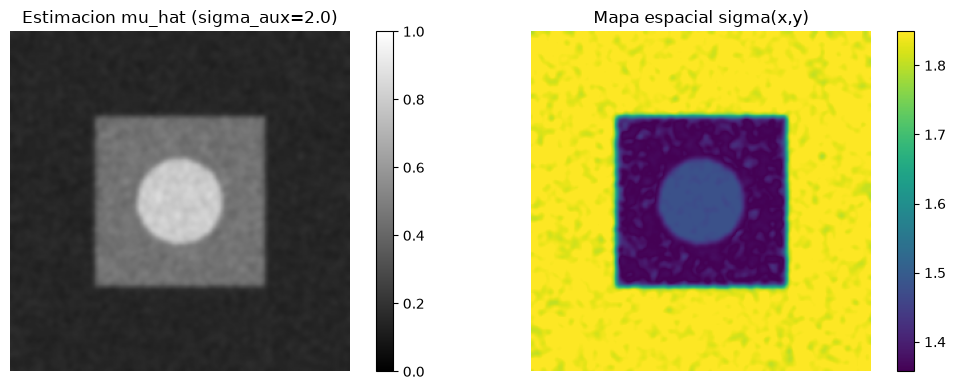

In [ ]:
intensidades_representativas = np.array([0.15, 0.45, 0.80])
nombres_region = list(mascaras)
sigma_opt_region = np.array([sigmas[optimos[name]] for name in nombres_region])
orden = np.argsort(intensidades_representativas)
mu_nodos = intensidades_representativas[orden]
sigma_nodos = sigma_opt_region[orden]
sigma_aux = 2.0
mu_hat = gaussian_filter(y, sigma=sigma_aux, mode="reflect", truncate=3.0)
sigma_map = np.interp(mu_hat, mu_nodos, sigma_nodos, left=sigma_nodos[0], right=sigma_nodos[-1])

print("Nodos de F(mu_hat):")
for mu, sigma in zip(mu_nodos, sigma_nodos):
    print(f"  mu={mu:.2f} -> sigma={sigma:.3f}")
print(f"Suavizado auxiliar: sigma_aux={sigma_aux}; mapa sigma en [{sigma_map.min():.3f}, {sigma_map.max():.3f}]")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im0 = ax[0].imshow(mu_hat, cmap="gray", vmin=0, vmax=1); ax[0].set_title(f"Estimacion mu_hat (sigma_aux={sigma_aux})")
im1 = ax[1].imshow(sigma_map, cmap="viridis"); ax[1].set_title("Mapa espacial sigma(x,y)")
for a in ax: a.set_axis_off()
fig.colorbar(im0, ax=ax[0], fraction=0.046); fig.colorbar(im1, ax=ax[1], fraction=0.046)
plt.tight_layout()

#### 5. Filtrado adaptativo y comparacion

Calculamos los filtros globales en las escalas nodales y se mezcla cada pixel segun su `sigma(x,y)`. Esto aproxima el filtro local de ancho variable y permite inspeccionar directamente como cambia la escala en el plano.

RMSE                         global      fondo      cuadrado    circulo
Sin filtrado         0.078170   0.061416   0.106228   0.143646
Mejor global         0.024104   0.016884   0.036971   0.043401
Adaptativo           0.024234   0.016884   0.036990   0.044789


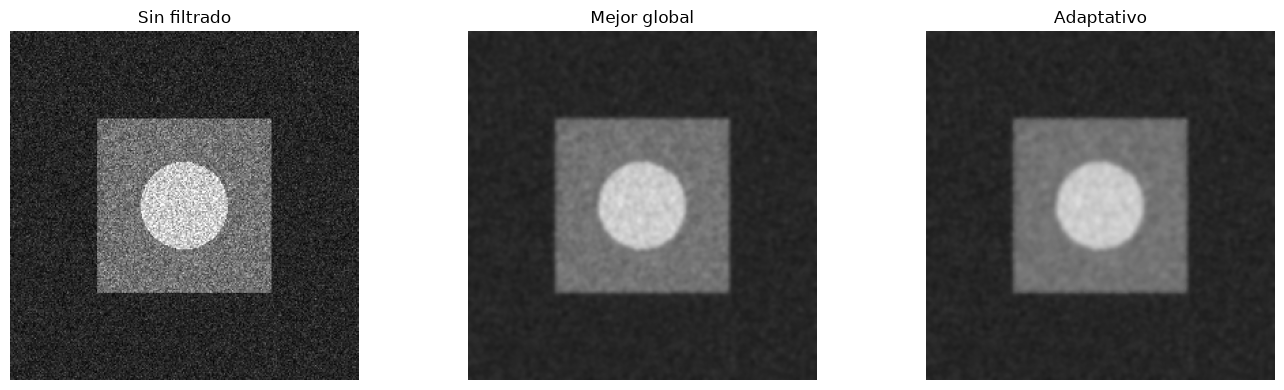

In [6]:
respuestas_nodales = np.stack([filtradas[float(sigma)] for sigma in sigma_nodos], axis=0)
posicion = np.interp(sigma_map, sigma_nodos, np.arange(len(sigma_nodos)))
i0 = np.floor(posicion).astype(int)
i1 = np.minimum(i0 + 1, len(sigma_nodos) - 1)
peso = posicion - i0
filas = np.arange(NPIX)[:, None]
columnas = np.arange(NPIX)[None, :]
adaptativa = (1 - peso) * respuestas_nodales[i0, filas, columnas] + peso * respuestas_nodales[i1, filas, columnas]

comparacion = {"Sin filtrado": y, "Mejor global": best_global, "Adaptativo": adaptativa}
tabla = {}
for name, estimate in comparacion.items():
    tabla[name] = [rmse(x, estimate)] + [rmse(x, estimate, mask) for mask in mascaras.values()]
print("RMSE                         global      fondo      cuadrado    circulo")
for name, values in tabla.items():
    print(f"{name:18s} " + " ".join(f"{value:10.6f}" for value in values))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, image) in zip(axes, comparacion.items()):
    ax.imshow(image, cmap="gray", vmin=0, vmax=1); ax.set_title(name); ax.set_axis_off()
plt.tight_layout()


#### 6. Fronteras, discontinuidades y modificacion propuesta

La estimacion auxiliar suaviza las fronteras, por lo que `sigma(x,y)` cambia de forma continua en lugar de saltar exactamente en el borde. Una modificacion simple es aumentar `sigma_aux` para suavizar el mapa, pero eso tambien puede desplazar la estimacion cerca de objetos pequenos. Otra opcion conservadora es restringir el rango de escalas y usar una transicion continua, que es la estrategia adoptada aqui mediante la interpolacion lineal.

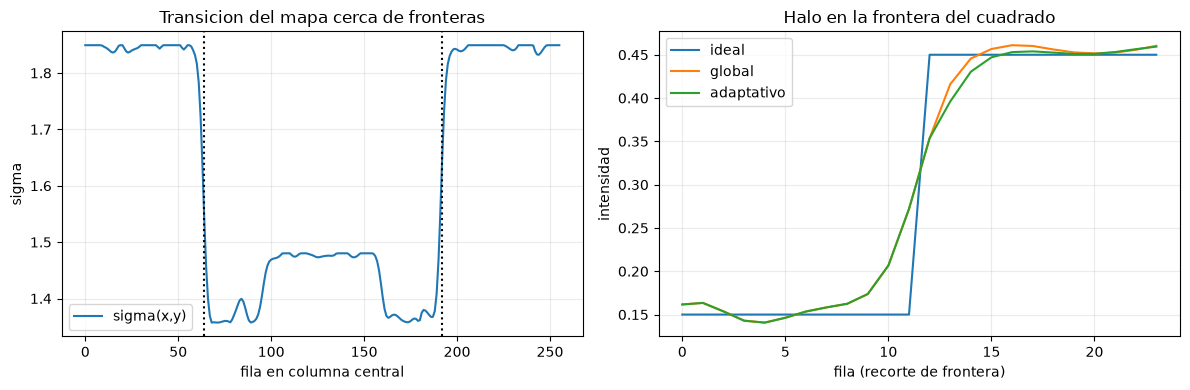

In [7]:
columna_central = NPIX // 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sigma_map[:, columna_central], label="sigma(x,y)")
axes[0].axvline(64, color="k", linestyle=":"); axes[0].axvline(192, color="k", linestyle=":")
axes[0].set(xlabel="fila en columna central", ylabel="sigma", title="Transicion del mapa cerca de fronteras")
axes[0].grid(alpha=0.25); axes[0].legend()
recorte = slice(52, 76)
axes[1].plot(x[:, columna_central][recorte], label="ideal")
axes[1].plot(best_global[:, columna_central][recorte], label="global")
axes[1].plot(adaptativa[:, columna_central][recorte], label="adaptativo")
axes[1].set(xlabel="fila (recorte de frontera)", ylabel="intensidad", title="Halo en la frontera del cuadrado")
axes[1].grid(alpha=0.25); axes[1].legend()
plt.tight_layout()